# Analyze difference between current headroom and projected electric grid load

This notebook analyzes the difference between the hosting capacity calculated utilizing current ICA data and projected electricity needs in California at the census tract level.

In [53]:
# load libraries
import pandas as pd 
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

In [48]:
# load in data
load_projected = pd.read_csv('/../../capstone/electrigrid/data/projected_load/tract_scenario_comparison.csv')
tract_summary = pd.read_csv('/../../capstone/electrigrid/data/projected_load/tract_summary.csv')
sce_hostcap = gpd.read_parquet('/../../capstone/electrigrid/data/census_hosting_capacity/sce_census_map_new.parquet')

# Investigate the tract summary data

In [33]:
tract_summary

,tract_id,scenario,annual_heating,peak_heating,peak_hour_heating,annual_cooling,peak_cooling,peak_hour_cooling,annual_hvac,peak_hvac,...,monthly_average_peak_exports_m03,monthly_average_peak_exports_m04,monthly_average_peak_exports_m05,monthly_average_peak_exports_m06,monthly_average_peak_exports_m07,monthly_average_peak_exports_m08,monthly_average_peak_exports_m09,monthly_average_peak_exports_m10,monthly_average_peak_exports_m11,monthly_average_peak_exports_m12
0,101050101,baseline,2355214.704,2472.808,1303,6637557.742,5576.662,4936,9.049241e+06,5590.470,...,1450.209626,1833.681377,1925.371581,1700.288787,1331.944806,1490.284293,1598.494210,1495.433939,969.630944,856.646095
1,101050102,baseline,2270635.655,2225.642,1303,3836218.190,3429.123,4936,6.142196e+06,3437.887,...,565.807475,727.653351,776.119432,698.827671,563.063739,613.761342,654.739613,603.548389,383.965592,327.047146
2,101050201,baseline,1507129.516,1523.182,1278,2876298.696,2485.575,4936,4.408875e+06,2496.747,...,158.370717,198.168605,210.526255,188.158894,150.604208,165.391451,176.539408,161.680260,100.981237,88.425195
3,101050202,baseline,2591524.081,2324.490,1272,3525976.409,3128.553,4936,6.146741e+06,3139.377,...,131.507766,164.269276,173.048946,153.991553,122.185436,135.593279,144.068135,134.811911,85.319428,74.025202
4,101050301,baseline,1062507.516,1051.209,1277,2414380.377,2237.497,4936,3.496785e+06,2242.501,...,593.455756,741.788015,773.607302,673.806714,524.436341,590.561161,640.429973,603.156111,394.726014,356.693877
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18079,99003906,high,1719231.308,2243.824,1302,4207000.506,3211.390,4936,5.964284e+06,3223.346,...,383.247966,665.251178,690.472134,523.604513,194.230573,300.051751,371.564583,387.353959,185.448970,60.907252
18080,99003907,high,2398806.229,3365.878,1303,9396687.363,7891.053,4936,1.185637e+07,7913.257,...,964.646567,1595.539565,1621.402697,1147.501466,450.938790,662.854387,799.109324,868.029848,488.027393,226.569533
18081,99003908,high,1068847.430,1314.966,1303,2001602.833,1646.402,4936,3.090531e+06,1654.150,...,200.699913,367.139869,396.191972,327.814842,155.414983,216.683595,231.372468,229.347478,87.068210,28.059093
18082,99003909,high,2071215.277,2595.438,1302,7018196.062,5675.536,4936,9.137991e+06,5691.564,...,613.824155,1026.484421,1031.436301,761.895102,351.567681,471.172587,564.965073,597.766374,327.811454,141.318573


The `tract_summary` is the data for the baseline. This won't be used further in this investigation. 

## Investigate Projected Load data

In [49]:
load_projected

,tract_id,annual_heating_baseline,peak_heating_baseline,peak_hour_heating_baseline,annual_cooling_baseline,peak_cooling_baseline,peak_hour_cooling_baseline,annual_hvac_baseline,peak_hvac_baseline,peak_hour_hvac_baseline,...,pct_increase_monthly_average_peak_exports_m03,pct_increase_monthly_average_peak_exports_m04,pct_increase_monthly_average_peak_exports_m05,pct_increase_monthly_average_peak_exports_m06,pct_increase_monthly_average_peak_exports_m07,pct_increase_monthly_average_peak_exports_m08,pct_increase_monthly_average_peak_exports_m09,pct_increase_monthly_average_peak_exports_m10,pct_increase_monthly_average_peak_exports_m11,pct_increase_monthly_average_peak_exports_m12
0,101050101,2355214.704,2472.808,1303,6637557.742,5576.662,4936,9.049241e+06,5590.470,4936,...,45.124032,59.776797,62.726066,54.604039,30.887606,38.191827,39.879113,38.829196,20.096738,9.059913
1,101050102,2270635.655,2225.642,1303,3836218.190,3429.123,4936,6.142196e+06,3437.887,4936,...,62.475768,82.018839,83.649028,69.599404,30.042981,45.787471,53.004921,55.495222,27.575736,9.307794
2,101050201,1507129.516,1523.182,1278,2876298.696,2485.575,4936,4.408875e+06,2496.747,4936,...,148.455989,191.512217,194.126877,167.827969,82.771258,116.739782,137.229268,140.855593,82.776129,50.921550
3,101050202,2591524.081,2324.490,1272,3525976.409,3128.553,4936,6.146741e+06,3139.377,4936,...,195.809506,250.741196,254.917695,211.899277,85.462427,138.467900,175.994677,185.914195,103.194909,57.780798
4,101050301,1062507.516,1051.209,1277,2414380.377,2237.497,4936,3.496785e+06,2242.501,4936,...,41.179062,53.806938,54.653630,44.065369,23.851800,30.238548,32.918991,33.853377,20.012565,13.345708
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9037,99003906,1567539.817,1675.641,1303,4007163.925,3009.648,4936,5.612756e+06,3021.604,4936,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9038,99003907,1643612.243,1880.696,1303,9027033.800,7425.407,4936,1.073153e+07,7447.611,4936,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9039,99003908,980829.110,1144.821,1303,1899860.020,1496.900,4936,2.900770e+06,1504.648,4936,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9040,99003909,1688330.711,1672.609,1303,6871341.492,5477.952,4936,8.608252e+06,5493.980,4936,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
load_projected.shape

(9042, 209)

There are 209 columns let's see which are the most important for us when looking at projected load data.

In [36]:
# subset for what was included in the readme
load_projected = load_projected[['tract_id', 
                                 'annual_pv_grid_baseline', 
                                 'peak_pv_grid_baseline',
                                 'annual_total_baseline',
                                 'peak_total_baseline',
                                 'annual_net_baseline',
                                 'peak_net_baseline',
                                 'annual_total_high',
                                 'annual_net_high',
                                 'pct_increase_annual_pv_grid',
                                 'p95_daily_peak_total_baseline',
                                 'p95_daily_peak_net_baseline',
                                 'p95_daily_peak_exports_baseline',
                                 'pct_increase_annual_total',
                                 'pct_increase_peak_total',
                                 'pct_increase_annual_net',
                                 'pct_increase_peak_net',
                                 'pct_increase_p95_daily_peak_total',
                                 'pct_increase_p95_daily_peak_net',
                                 'pct_increase_p95_daily_peak_exports']]

In [23]:
load_projected.head()

,tract_id,annual_pv_grid_baseline,peak_pv_grid_baseline,annual_total_baseline,peak_total_baseline,annual_net_baseline,peak_net_baseline,annual_total_high,annual_net_high,pct_increase_annual_pv_grid,p95_daily_peak_total_baseline,p95_daily_peak_net_baseline,p95_daily_peak_exports_baseline,pct_increase_annual_total,pct_increase_peak_total,pct_increase_annual_net,pct_increase_peak_net,pct_increase_p95_daily_peak_total,pct_increase_p95_daily_peak_net,pct_increase_p95_daily_peak_exports
0,101050101,2.959735e+06,2353.013571,2.418041e+07,7541.596242,2.165261e+07,6898.598399,2.569669e+07,2.013312e+07,35.885901,6785.780642,6051.076242,2103.024550,6.270672,5.083126,-7.017575,-7.658958,4.775366,-14.575055,69.942161
1,101050102,1.228744e+06,934.608793,1.478831e+07,4540.656719,1.388782e+07,4329.817895,1.572635e+07,1.324041e+07,44.122090,4047.703895,3758.999385,838.258763,6.343100,7.096314,-4.661723,-6.223291,6.411754,-9.571121,91.817151
2,101050201,3.304704e+05,252.035794,1.068719e+07,3870.539240,1.043091e+07,3814.111310,1.159768e+07,1.027810e+07,110.129063,2987.648443,2906.069323,228.615048,8.519428,4.290516,-1.464980,-2.510222,6.321410,-8.192671,216.261314
3,101050202,2.713197e+05,212.348648,1.334280e+07,4788.374193,1.313129e+07,4706.692714,1.455011e+07,1.312264e+07,133.994954,3675.509865,3600.023866,189.725772,9.048441,5.503752,-0.065857,-0.124648,8.068247,-3.404109,281.915351
4,101050301,1.202807e+06,945.061611,8.804029e+06,2933.921079,7.788774e+06,2702.590338,9.551153e+06,7.461803e+06,32.629535,2599.003287,2333.947411,850.930057,8.486157,8.183152,-4.197976,-0.988236,7.508347,-9.124383,61.359333


In [37]:
print(load_projected['annual_total_high'].min())
print(load_projected['annual_total_high'].max())

9731.136
63425074.50381643


Assumption:  These values are for the entire census tract for all of the households.

## View hosting capacity calculations

In [38]:
sce_hostcap.head()

,GEOID,zillow_tract_hh_count,avg_DER_remain_pv_hh,avg_DER_remain_load_hh,avg_DER_total_pv_hh,geometry
0,06065042516,776.0,6.02214,2.715849,7.550272,"POLYGON ((254831.161 -450428.536, 254879.224 -..."
1,06065042716,2174.0,0.00000,0.099297,4.067808,"POLYGON ((252988.226 -477491.812, 253070.244 -..."
2,06065042717,1781.0,NaN,NaN,NaN,"POLYGON ((253204.987 -475305.031, 253228.177 -..."
3,06065042902,1284.0,NaN,NaN,NaN,"POLYGON ((245709.226 -466855.471, 245710.230 -..."
4,06065042903,1417.0,NaN,NaN,NaN,"POLYGON ((244083.685 -461694.249, 244084.463 -..."


Since the projected data contains the total data for the whole census tract we need to work at the same scale.

In [39]:
# calculate the total headroom for the whole census tract
sce_hostcap['total_DER'] = sce_hostcap['zillow_tract_hh_count'] * sce_hostcap['avg_DER_remain_load_hh']

In [40]:
print(sce_hostcap['total_DER'].min())
print(sce_hostcap['total_DER'].max())

0.0
38790.15533951731


## Convert the GeoID to match between the dataframes

The `projected_load` data doesn't use the `0606` prefix for the GeoID so we'll remove it from the utility hosting capacity data so that they match.

In [41]:
# remove the unnecessary pre-crusor number from the geoid
sce_hostcap['GEOID'] = sce_hostcap['GEOID'].str.replace('06', '', regex = False)

In [42]:
# change the tract_id column to a character instead of numeric
load_projected['tract_id'] = load_projected['tract_id'].astype('string')

/tmp/ipykernel_4167508/210256278.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  load_projected['tract_id'] = load_projected['tract_id'].astype('string')


In [43]:
sce_hostcap

,GEOID,zillow_tract_hh_count,avg_DER_remain_pv_hh,avg_DER_remain_load_hh,avg_DER_total_pv_hh,geometry,total_DER
0,5042516,776.0,6.022140,2.715849,7.550272,"POLYGON ((254831.161 -450428.536, 254879.224 -...",2107.499042
1,5042716,2174.0,0.000000,0.099297,4.067808,"POLYGON ((252988.226 -477491.812, 253070.244 -...",215.871394
2,5042717,1781.0,NaN,NaN,NaN,"POLYGON ((253204.987 -475305.031, 253228.177 -...",NaN
3,5042902,1284.0,NaN,NaN,NaN,"POLYGON ((245709.226 -466855.471, 245710.230 -...",NaN
4,5042903,1417.0,NaN,NaN,NaN,"POLYGON ((244083.685 -461694.249, 244084.463 -...",NaN
...,...,...,...,...,...,...,...
5099,037503705,1301.0,1.213680,0.577934,1.844096,"POLYGON ((185472.551 -453389.032, 185472.445 -...",751.891549
5100,037602601,1712.0,NaN,NaN,NaN,"POLYGON ((154774.085 -454787.458, 154773.975 -...",NaN
5101,081605800,259.0,0.575408,0.045678,2.358458,"POLYGON ((-207702.617 -47686.566, -207665.608 ...",11.830497
5102,081605300,219.0,0.053868,0.000000,2.114660,"POLYGON ((-209156.957 -45748.118, -209152.997 ...",0.000000


# Subtract the projected load from the existing headroom

In [44]:
# join the two dataframes 
join = pd.merge(sce_hostcap, load_projected, how = "inner", left_on = 'GEOID', right_on = 'tract_id')


In [ ]:
# view the shape of the joined dataframe
join.shape

(378, 27)

In [ ]:
# view the head of the dataframe
join.head()


,GEOID,zillow_tract_hh_count,avg_DER_remain_pv_hh,avg_DER_remain_load_hh,avg_DER_total_pv_hh,geometry,total_DER,tract_id,annual_pv_grid_baseline,peak_pv_grid_baseline,...,p95_daily_peak_total_baseline,p95_daily_peak_net_baseline,p95_daily_peak_exports_baseline,pct_increase_annual_total,pct_increase_peak_total,pct_increase_annual_net,pct_increase_peak_net,pct_increase_p95_daily_peak_total,pct_increase_p95_daily_peak_net,pct_increase_p95_daily_peak_exports
0,101050302,798.0,1.732709,0.384243,3.536127,"POLYGON ((-140361.049 123691.282, -140359.761 ...",306.626096,101050302,1.373032e+06,1054.710374,...,5085.395639,4820.371669,933.414488,6.732087,6.930773,-4.119477,-3.448763,6.178551,-10.717286,99.904678
1,101050501,527.0,5.629988,0.277609,6.816154,"POLYGON ((-146691.879 125234.951, -146664.662 ...",146.300048,101050501,2.430082e+06,1896.173920,...,5803.850920,5252.047201,1710.566139,6.219680,4.911974,-9.204254,-10.373387,4.417511,-16.209490,82.671043
2,113010102,156.0,1.096585,0.327117,1.264784,"POLYGON ((-144446.856 84577.529, -144444.616 8...",51.030215,113010102,0.000000e+00,0.000000,...,1170.622615,1170.622615,0.000000,12.349746,16.260747,-1.885703,-4.406048,12.557171,-7.399534,NaN
3,113011102,758.0,2.168216,0.567775,2.711391,"POLYGON ((-153456.885 73385.547, -153452.145 7...",430.373549,113011102,7.783400e+05,586.948967,...,3694.932959,3482.718529,538.482899,6.161647,6.097378,-8.983832,1.264009,6.276627,-6.279694,195.104394
4,113010501,30.0,1.147518,0.968405,1.970383,"POLYGON ((-158590.318 60359.387, -158586.055 6...",29.052163,113010501,1.233281e+06,884.848656,...,2618.550613,2431.440663,826.615395,4.738319,2.716035,3.599238,3.768015,2.832668,3.068737,12.442227


In [ ]:
# calculate the difference between the headroom and the projected load
join['diff_proj_load'] = join['total_DER'] - join['annual_net_high']

In [64]:
min_diff = join['diff_proj_load'].min()
max_diff = join['diff_proj_load'].max()

In [65]:
min_diff

-28246660.93684079

# Map the differences

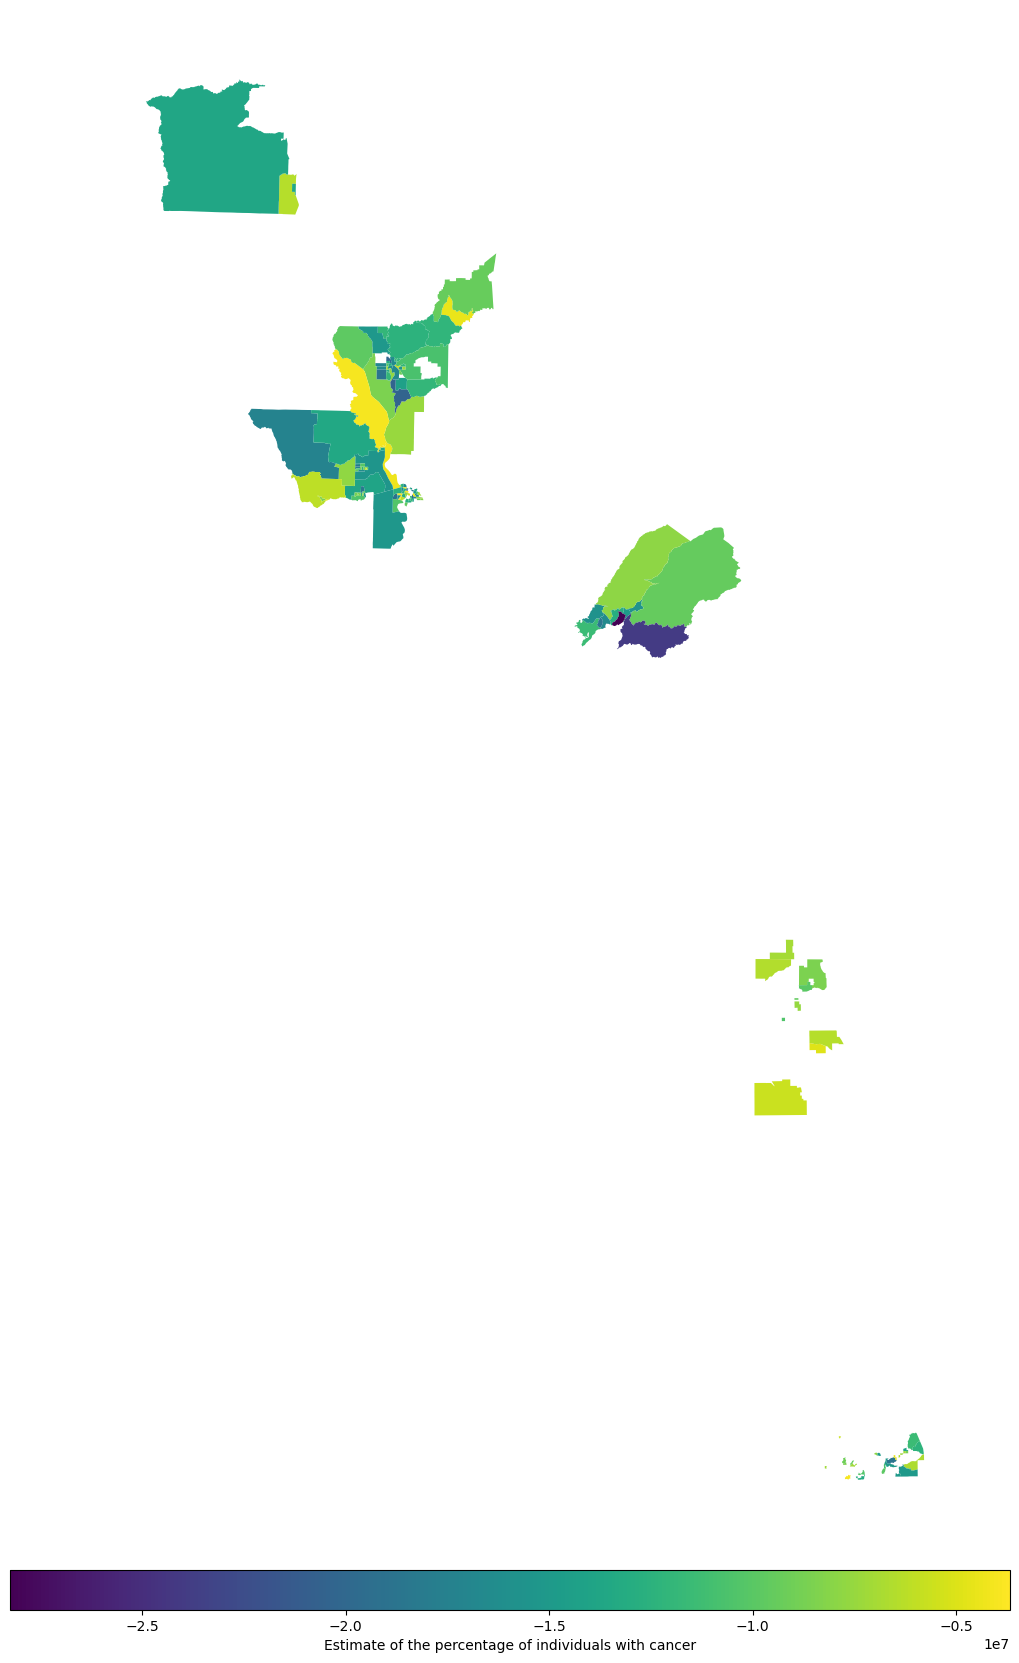

In [ ]:
fig, ax = plt.subplots(figsize = (20, 20))
ax.axis('off')

join.plot('diff_proj_load',
          ax = ax)

# Add shared colorbar at the bottom
sm = plt.cm.ScalarMappable( norm=plt.Normalize(vmin= min_diff, vmax=max_diff))
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Difference in load to ')